In [62]:
from langgraph.graph import StateGraph , START ,END
from dotenv import load_dotenv
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from typing import Annotated , TypedDict
from pydantic import BaseModel , Field
import operator

In [63]:
load_dotenv()

True

In [64]:
model = ChatNVIDIA(model='nvidia/nemotron-3-super-120b-a12b')

In [65]:
class UPSCState(TypedDict):

    essay : str
    language_feedback :str
    analysis_feedback : str
    clarity_feedback : str
    overall_feedback : str
    indivudal_score : Annotated[list[int], operator.add]
    average_score : float

In [66]:
class Evaluation_schema(BaseModel):

    feedback : str = Field(description="detailed feedback of the essay")
    score : int = Field(description="score the out of 10",ge=0,le=10)

In [67]:
structured_model = model.with_structured_output(Evaluation_schema)

In [68]:
def language_feedback(state:UPSCState):
    prompt = f"Evaluate the language quality of the following essay and provide a feedback and score out of 10\n {state['essay']}"
    output = structured_model.invoke(prompt)

    return {'language_feedback':output.feedback,'indivudal_score':[output.score]}

In [76]:
def analysis_feedback(state:UPSCState):
    prompt = f"Evaluate the depth of analysis of the following essay and provide a feedback and score out of 10\n {state['essay']}"
    output = structured_model.invoke(prompt)

    return {'analysis_feedback': output.feedback,'indivudal_score':[output.score]}

In [70]:
def clarity_feedback(state:UPSCState):
    prompt = f"Evaluate the clarity of thought of the following essay and provide a feedback and score out of 10\n {state['essay']}"
    output = structured_model.invoke(prompt)

    return {'clarity_feedback':output.feedback,'indivudal_score':[output.score]}

In [71]:
def final_evaluation(state:UPSCState):
    prompt = f"Based on the following feedback create a summarized feedback\n language_feedback - {state['language_feedback']}\n analysis_feedback - {state['analysis_feedback']}\n clarity_feedback - {state['clarity_feedback']}"
    overall_feedback = model.invoke(prompt).content

    # average score
    average_Score = sum(state['indivudal_score'])/len(state['indivudal_score'])

    return {'overall_feedback':overall_feedback,'average_score':average_Score}


In [77]:
graph = StateGraph(UPSCState)

graph.add_node('language_feedback',language_feedback)
graph.add_node('analysis_feedback',analysis_feedback)
graph.add_node('clarity_feedback',clarity_feedback)
graph.add_node('final_evaluation',final_evaluation)

graph.add_edge(START,'language_feedback')
graph.add_edge(START,'analysis_feedback')
graph.add_edge(START,'clarity_feedback')

graph.add_edge('language_feedback','final_evaluation')
graph.add_edge('analysis_feedback','final_evaluation')
graph.add_edge('clarity_feedback','final_evaluation')

graph.add_edge('final_evaluation',END)

workflow = graph.compile()


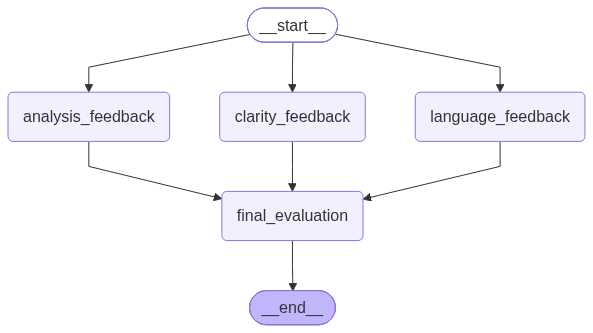

In [78]:
workflow

In [79]:
essay = """"India is not merely a geographical expression but a civilisational idea shaped by centuries of cultural evolution, interaction and synthesis. Its richness in culture lies not only in the antiquity of its traditions but also in their remarkable diversity, continuity and capacity to adapt. From the snow-clad Himalayas to the coastal regions, from tribal communities to metropolitan cities, India presents a mosaic of languages, customs, art forms, philosophies and ways of life.

Indian culture has evolved through the interaction of numerous communities and civilisations. The legacy of the Indus Valley Civilisation, the Vedic traditions, Buddhism, Jainism, Bhakti and Sufi movements, as well as various regional traditions, have contributed to this cultural landscape. Rather than remaining isolated, these influences interacted and produced a distinctive culture characterised by accommodation and synthesis. The principle of “unity in diversity” therefore represents not merely a slogan but a historical reality.

India’s linguistic diversity is one of its greatest cultural assets. The Constitution recognises 22 Scheduled Languages, while hundreds of other languages and dialects continue to be spoken across the country. Literature in Sanskrit, Tamil, Kannada, Bengali, Hindi, Urdu, Malayalam and numerous other languages reflects different experiences while expressing universal human concerns. Classical traditions such as Bharatanatyam, Kathak, Kathakali and Odissi coexist with folk forms such as Yakshagana, Bihu and Garba, demonstrating the depth of India’s performing arts.

Indian festivals further illustrate this cultural plurality. Diwali, Eid, Christmas, Guru Nanak Jayanti, Pongal, Onam, Bihu and numerous regional festivals are celebrated with distinct rituals and customs. These occasions often transcend their religious origins and become platforms for social interaction and community participation. Similarly, Indian cuisine reflects centuries of migration, trade and cultural exchange. Spices, cooking methods and food traditions vary enormously from region to region, yet together they form an important component of India’s cultural identity.

India’s cultural wealth also extends to its tangible heritage. Ancient temples, stupas, forts, mosques, churches, monasteries and archaeological sites reveal the artistic and architectural achievements of different periods. Sites such as Ajanta and Ellora, the temples of Khajuraho, the monuments of Hampi and the historic cities of Rajasthan demonstrate how architecture became a medium through which societies expressed their beliefs, aspirations and technological capabilities.

However, cultural richness also brings responsibilities. Globalisation, rapid urbanisation, commercialisation and the decline of traditional occupations pose challenges to indigenous art forms, languages and knowledge systems. Cultural preservation must therefore not mean freezing traditions in the past. Instead, traditional knowledge and artistic practices should be documented, taught to younger generations and provided sustainable economic opportunities. Digital technology can also help communities preserve and promote their heritage.

Ultimately, India’s cultural strength lies in its ability to preserve continuity while embracing change. Its civilisation has survived not because it remained static, but because it continually absorbed, transformed and enriched itself through interaction with diverse influences. In an increasingly polarised world, India’s cultural experience offers a valuable lesson: diversity need not be a source of division; when supported by mutual respect and constitutional values, it can become a source of collective strength. India’s cultural richness is therefore not simply a heritage inherited from the past, but a living resource that can shape a more inclusive and harmonious future."""

In [82]:
essay_2 ="""India is a country which is very rich in culture and it has many cultures from different places. India is having many states and every state has different culture, food, language and festivals. Because of this India is called unity in diversity. But sometimes this diversity also creates many problems because people are different and they have different thinking.

India has many festivals like Diwali, Eid, Christmas, Pongal and many other festivals. These festivals are celebrated by many people and it shows that India has culture. But nowadays people are not following culture like old people were following. Young people are more interested in western culture and social media. So Indian culture is getting affected but still it is there.

India also has many languages. People speak Hindi, Kannada, Tamil, Telugu, Bengali and many other languages. Every language has their own literature and history. But because there are so many languages sometimes people have communication problem with each other. English is also used for communication but it is not Indian traditional language. Still it has become important because of education and jobs.

Indian food is also very famous and different states have different foods. South India has dosa, idli and other foods and North India has different foods like roti and other dishes. Indian food also has many spices. This shows that India has a lot of variety in food. But now fast food is becoming popular among young people and traditional food is becoming less important.

India has many historical places also. There are temples, forts, mosques and other buildings. These buildings tell about the history of India. But many historical places are not properly maintained. Pollution and people damaging places can cause problems. Government should protect these places but sometimes it is not done properly.

Indian culture is good but there are also some bad things in society. Some traditions can create inequality and discrimination. In the name of culture, sometimes people support old practices which should not be followed now. Therefore we should not blindly follow everything which is called culture.

In conclusion, India has a very large culture and many different traditions. It is good that India has so much diversity, but there are also challenges in protecting it. Modernisation is changing Indian culture and some traditions may disappear. We should preserve good traditions and remove bad practices. India should move forward with development while also keeping its culture. This will help India remain culturally rich in the future."""

In [83]:
inital_state = {'essay':essay_2}

workflow.invoke(inital_state)

{'essay': 'India is a country which is very rich in culture and it has many cultures from different places. India is having many states and every state has different culture, food, language and festivals. Because of this India is called unity in diversity. But sometimes this diversity also creates many problems because people are different and they have different thinking.\n\nIndia has many festivals like Diwali, Eid, Christmas, Pongal and many other festivals. These festivals are celebrated by many people and it shows that India has culture. But nowadays people are not following culture like old people were following. Young people are more interested in western culture and social media. So Indian culture is getting affected but still it is there.\n\nIndia also has many languages. People speak Hindi, Kannada, Tamil, Telugu, Bengali and many other languages. Every language has their own literature and history. But because there are so many languages sometimes people have communication p